# Notebook 18 — Balanced Multi-Class Training

## Diabetic Retinopathy: 5-Grade Classification with Balanced Sampling

**Key difference from Notebook 04:** This notebook addresses the class imbalance problem:

| Grade | Original Count | Ratio |
|-------|---------------|-------|
| G0 (No DR) | 1,258 | 1:1 |
| G1 (Mild) | 228 | 1:5.5 |
| G2 (Moderate) | 665 | 1:1.9 |
| G3 (Severe) | 127 | 1:9.9 |
| G4 (Proliferative) | 195 | 1:6.5 |

### Balancing Strategies Used:
1. **WeightedRandomSampler** — each batch sees roughly equal grades
2. **Class-weighted CrossEntropyLoss** — higher penalty for misclassifying rare grades
3. **Enhanced augmentation for minority classes** — extra augmentation via Mixup
4. **Label smoothing** — prevents overconfident predictions on majority classes

### Architecture (same as Notebook 04):
- EfficientNet-B3 backbone (ImageNet pretrained)
- Classifier: `Sequential(Dropout(0.4), Linear(1536, 5))`
- Two-phase: frozen backbone → full fine-tune

**Run on M1 Pro** (MPS device)

In [2]:
# ============================================================
# 1. Imports & Configuration
# ============================================================
import os
import gc
import copy
import json
import time
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.use_deterministic_algorithms(False)

set_seed(SEED)

# ── Device ──
def get_device() -> torch.device:
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# ── Configuration ──
CONFIG = {
    "seed": SEED,
    "device": str(DEVICE),
    "data_root": ".",
    "splits_dir": "splits_aptos",
    "models_dir": "models",
    "figures_dir": "figures",
    # Model
    "model_name": "efficientnet_b3",
    "pretrained": True,
    "num_classes": 5,
    "dropout_rate": 0.4,
    # Image
    "image_size": 384,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    # Training — Phase 1 (frozen backbone)
    "phase1_epochs": 5,
    "phase1_lr": 1e-3,
    # Training — Phase 2 (full fine-tune)
    "phase2_epochs": 40,
    "phase2_lr": 1e-4,
    "weight_decay": 1e-4,
    # Scheduler
    "scheduler_T0": 10,
    "scheduler_Tmult": 2,
    # DataLoader
    "batch_size": 16,
    "num_workers": 0,
    "pin_memory": False,
    # Regularisation
    "grad_clip_max_norm": 1.0,
    "label_smoothing": 0.1,
    # Mixup
    "mixup_alpha": 0.2,
    "mixup_prob": 0.3,
    # Early stopping
    "early_stopping_patience": 12,
    # Mixed precision
    "use_amp": DEVICE.type in ("cuda",),
    # Balancing
    "use_weighted_sampler": True,
    "use_class_weights": True,
    "sampler_power": 0.5,  # <1 = softer balance, 1 = full inverse freq
}

ROOT = Path(CONFIG["data_root"])
MODELS_DIR = ROOT / CONFIG["models_dir"]
FIG_DIR = ROOT / CONFIG["figures_dir"]
SPLITS_DIR = ROOT / CONFIG["splits_dir"]
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device       : {DEVICE}")
print(f"Model        : {CONFIG['model_name']}")
print(f"Num classes  : {CONFIG['num_classes']}")
print(f"Image size   : {CONFIG['image_size']}")
print(f"Phase 1      : {CONFIG['phase1_epochs']} epochs, lr={CONFIG['phase1_lr']}")
print(f"Phase 2      : {CONFIG['phase2_epochs']} epochs, lr={CONFIG['phase2_lr']}")
print(f"Batch size   : {CONFIG['batch_size']}")
print(f"Balancing    : WeightedSampler={CONFIG['use_weighted_sampler']}, ClassWeights={CONFIG['use_class_weights']}")
print(f"Mixup        : alpha={CONFIG['mixup_alpha']}, prob={CONFIG['mixup_prob']}")
print(f"Early stop   : patience={CONFIG['early_stopping_patience']}")
print("Configuration loaded ✓")

Device       : mps
Model        : efficientnet_b3
Num classes  : 5
Image size   : 384
Phase 1      : 5 epochs, lr=0.001
Phase 2      : 40 epochs, lr=0.0001
Batch size   : 16
Balancing    : WeightedSampler=True, ClassWeights=True
Mixup        : alpha=0.2, prob=0.3
Early stop   : patience=12
Configuration loaded ✓


## 2. Dataset with Enhanced Augmentation

In [4]:
# ============================================================
# 2. Augmentation & Dataset
# ============================================================

def get_train_transforms(image_size: int, mean: list, std: list) -> A.Compose:
    """Enhanced training augmentation pipeline."""
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1, scale_limit=0.15, rotate_limit=30,
            border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5
        ),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20),
            A.RandomGamma(gamma_limit=(80, 120)),
        ], p=0.4),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5)),
            A.GaussNoise(std_range=(0.02, 0.05)),
        ], p=0.2),
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(int(image_size * 0.05), int(image_size * 0.15)),
            hole_width_range=(int(image_size * 0.05), int(image_size * 0.15)),
            fill="random", p=0.3,
        ),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])


def get_val_transforms(image_size: int, mean: list, std: list) -> A.Compose:
    """Validation transform pipeline."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])


class DRDataset(Dataset):
    """Diabetic Retinopathy multi-class dataset."""

    def __init__(self, dataframe: pd.DataFrame, transform: A.Compose) -> None:
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        row = self.df.iloc[idx]
        img = cv2.imread(str(ROOT / row["preprocessed_path"]))
        if img is None:
            raise FileNotFoundError(f"Cannot read: {row['preprocessed_path']}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)
        image = augmented["image"]
        label = torch.tensor(row["dr_grade"], dtype=torch.long)
        return image, label


print("Dataset and transforms defined ✓")

Dataset and transforms defined ✓


## 3. Create Balanced DataLoaders

In [6]:
# ============================================================
# 3. Load Data & Create Balanced Samplers
# ============================================================

df_train = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_val = pd.read_csv(SPLITS_DIR / "val_split.csv")

print(f"Train: {len(df_train)} images")
print(f"Val  : {len(df_val)} images")

# ── Original distribution ──
print(f"\n{'Grade':<10} {'Count':>6} {'Pct':>6}  Bar")
print("-" * 50)
for g in range(5):
    c = (df_train['dr_grade'] == g).sum()
    pct = c / len(df_train) * 100
    bar = '█' * int(pct)
    print(f"Grade {g:<4} {c:>6} {pct:>5.1f}%  {bar}")

# ── Build transforms ──
train_tfm = get_train_transforms(CONFIG["image_size"], CONFIG["mean"], CONFIG["std"])
val_tfm = get_val_transforms(CONFIG["image_size"], CONFIG["mean"], CONFIG["std"])

train_ds = DRDataset(df_train, train_tfm)
val_ds = DRDataset(df_val, val_tfm)

# ── WeightedRandomSampler ──
# Each sample gets weight = 1 / (count of its class)
# This makes each class equally likely to be sampled per epoch
labels = df_train["dr_grade"].values
class_counts = np.bincount(labels, minlength=5).astype(np.float64)

if CONFIG["use_weighted_sampler"]:
    # Effective count: apply power < 1 for softer balancing
    # power=1.0 → full balance (all classes equal)
    # power=0.5 → square root balance (softer, keeps some natural distribution)
    effective_counts = class_counts ** CONFIG["sampler_power"]
    class_sample_weights = 1.0 / effective_counts
    class_sample_weights = class_sample_weights / class_sample_weights.sum()  # normalize
    
    # Assign weight per sample
    sample_weights = np.array([class_sample_weights[label] for label in labels])
    sample_weights = torch.from_numpy(sample_weights).double()
    
    # Number of samples per epoch = original dataset size
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_ds),
        replacement=True,
    )
    
    train_loader = DataLoader(
        train_ds, batch_size=CONFIG["batch_size"],
        sampler=sampler,  # replaces shuffle=True
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        drop_last=True,
    )
    
    # Show expected distribution
    expected_per_class = class_sample_weights * len(train_ds)
    print(f"\n{'Grade':<10} {'Original':>8} {'Expected':>10}  Ratio")
    print("-" * 50)
    for g in range(5):
        print(f"Grade {g:<4} {int(class_counts[g]):>8} {expected_per_class[g]:>10.0f}  {expected_per_class[g]/class_counts[g]:.2f}x")
    print(f"\nSampler power: {CONFIG['sampler_power']} (1.0=full balance, 0.5=soft balance)")
else:
    train_loader = DataLoader(
        train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
        num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"],
        drop_last=True,
    )
    print("\nUsing default shuffle (no weighted sampler)")

val_loader = DataLoader(
    val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=CONFIG["pin_memory"],
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

# ── Class weights for loss ──
if CONFIG["use_class_weights"]:
    class_weights = 1.0 / (class_counts + 1e-6)
    class_weights = class_weights / class_weights.sum() * CONFIG["num_classes"]
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    print(f"\nClass weights for loss: {class_weights}")
else:
    class_weights_tensor = None
    print("\nNo class weights (uniform loss)")

Train: 2473 images
Val  : 530 images

Grade       Count    Pct  Bar
--------------------------------------------------
Grade 0      1258  50.9%  ██████████████████████████████████████████████████
Grade 1       228   9.2%  █████████
Grade 2       665  26.9%  ██████████████████████████
Grade 3       127   5.1%  █████
Grade 4       195   7.9%  ███████

Grade      Original   Expected  Ratio
--------------------------------------------------
Grade 0        1258        238  0.19x
Grade 1         228        558  2.45x
Grade 2         665        327  0.49x
Grade 3         127        748  5.89x
Grade 4         195        603  3.09x

Sampler power: 0.5 (1.0=full balance, 0.5=soft balance)

Train batches: 154
Val batches  : 34

Class weights for loss: [0.20188914 1.11393219 0.38191961 1.99981527 1.30244379]


## 4. Model Architecture

In [8]:
# ============================================================
# 4. Model
# ============================================================

def create_multiclass_model(model_name="efficientnet_b3", pretrained=True,
                             num_classes=5, dropout_rate=0.4):
    model = timm.create_model(model_name, pretrained=pretrained)
    n_features = model.num_features  # 1536
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(n_features, num_classes),
    )
    return model, n_features

model, n_features = create_multiclass_model(
    CONFIG["model_name"], CONFIG["pretrained"],
    CONFIG["num_classes"], CONFIG["dropout_rate"],
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {CONFIG['model_name']}")
print(f"  Backbone features: {n_features}")
print(f"  Head: Dropout({CONFIG['dropout_rate']}) → Linear({n_features}, {CONFIG['num_classes']})")
print(f"  Total params: {total_params:,}")

Model: efficientnet_b3
  Backbone features: 1536
  Head: Dropout(0.4) → Linear(1536, 5)
  Total params: 10,703,917


## 5. Training Utilities

In [10]:
# ============================================================
# 5. Training Utilities
# ============================================================

def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.should_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        improved = (score > self.best_score + self.min_delta) if self.mode == "max" \
                   else (score < self.best_score - self.min_delta)
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                return True
        return False


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0.0; self.sum = 0.0; self.count = 0
    def update(self, val, n=1):
        self.sum += val * n; self.count += n; self.avg = self.sum / self.count


def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Backbone FROZEN — trainable params: {trainable:,}")


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  All layers UNFROZEN — trainable params: {trainable:,}")


def mixup_data(x, y, alpha=0.2):
    """Mixup: creates convex combinations of training examples.
    
    For imbalanced data, mixup helps by:
    - Creating virtual training examples between classes
    - Smoothing decision boundaries
    - Acting as data augmentation for minority classes
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute mixup loss."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print("Training utilities defined ✓")

Training utilities defined ✓


## 6. Training & Validation Functions

In [12]:
# ============================================================
# 6. Training & Validation with Mixup
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device,
                    grad_clip=1.0, use_amp=False, scaler=None,
                    mixup_alpha=0.0, mixup_prob=0.0):
    """Train one epoch with optional Mixup augmentation."""
    model.train()
    loss_meter = AverageMeter()
    all_labels = []
    all_preds = []

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Apply Mixup with probability
        use_mixup = mixup_alpha > 0 and random.random() < mixup_prob

        if use_amp and scaler is not None:
            with torch.amp.autocast("cuda"):
                if use_mixup:
                    mixed_images, targets_a, targets_b, lam = mixup_data(images, labels, mixup_alpha)
                    logits = model(mixed_images)
                    loss = mixup_criterion(criterion, logits, targets_a, targets_b, lam)
                else:
                    logits = model(images)
                    loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            if use_mixup:
                mixed_images, targets_a, targets_b, lam = mixup_data(images, labels, mixup_alpha)
                logits = model(mixed_images)
                loss = mixup_criterion(criterion, logits, targets_a, targets_b, lam)
            else:
                logits = model(images)
                loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        loss_meter.update(loss.item(), images.size(0))

        # For metrics, use original (non-mixed) predictions
        with torch.no_grad():
            if use_mixup:
                logits_clean = model(images)
                preds = torch.argmax(logits_clean, dim=1).cpu().numpy()
            else:
                preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss_meter.avg:.4f}")

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    acc = accuracy_score(all_labels, all_preds)
    qwk = quadratic_weighted_kappa(all_labels, all_preds)
    return loss_meter.avg, acc, qwk


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validate model."""
    model.eval()
    loss_meter = AverageMeter()
    all_labels = []
    all_preds = []

    pbar = tqdm(loader, desc="  Val  ", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss_meter.update(loss.item(), images.size(0))
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss_meter.avg:.4f}")

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    acc = accuracy_score(all_labels, all_preds)
    qwk = quadratic_weighted_kappa(all_labels, all_preds)
    return loss_meter.avg, acc, qwk


print("Training and validation functions defined ✓")

Training and validation functions defined ✓


## 7. Phase 1 — Train Head Only (Frozen Backbone)

In [14]:
# ============================================================
# 7. Phase 1 — Frozen backbone, train head only
# ============================================================
print("=" * 60)
print("PHASE 1: Frozen backbone — training classifier head only")
print("=" * 60)

freeze_backbone(model)

# Loss with class weights + label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=CONFIG["label_smoothing"],
)
print(f"  Loss: CrossEntropyLoss(weight=class_weights, label_smoothing={CONFIG['label_smoothing']})")

optimizer_p1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["phase1_lr"],
    weight_decay=CONFIG["weight_decay"],
)
print(f"  Optimizer: AdamW(lr={CONFIG['phase1_lr']}, wd={CONFIG['weight_decay']})")

scaler = torch.amp.GradScaler("cuda") if CONFIG["use_amp"] else None

history = {
    "epoch": [], "phase": [],
    "train_loss": [], "train_acc": [], "train_qwk": [],
    "val_loss": [], "val_acc": [], "val_qwk": [],
    "lr": [],
}

best_val_qwk = 0.0
best_model_state = None

print(f"\n{'Epoch':>6s} {'Phase':>7s} {'TrLoss':>8s} {'TrAcc':>7s} {'TrQWK':>7s} "
      f"{'VlLoss':>8s} {'VlAcc':>7s} {'VlQWK':>7s} {'LR':>10s} {'Best':>5s}")
print("-" * 85)

for epoch in range(1, CONFIG["phase1_epochs"] + 1):
    t0 = time.time()

    train_loss, train_acc, train_qwk = train_one_epoch(
        model, train_loader, criterion, optimizer_p1, DEVICE,
        grad_clip=CONFIG["grad_clip_max_norm"],
        use_amp=CONFIG["use_amp"], scaler=scaler,
        mixup_alpha=0, mixup_prob=0,  # No mixup in Phase 1
    )
    val_loss, val_acc, val_qwk = validate(model, val_loader, criterion, DEVICE)

    current_lr = optimizer_p1.param_groups[0]["lr"]
    is_best = val_qwk > best_val_qwk

    if is_best:
        best_val_qwk = val_qwk
        best_model_state = copy.deepcopy(model.state_dict())

    history["epoch"].append(epoch)
    history["phase"].append("phase1")
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_qwk"].append(train_qwk)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_qwk"].append(val_qwk)
    history["lr"].append(current_lr)

    marker = "  ★" if is_best else ""
    print(f"{epoch:6d} {'P1':>7s} {train_loss:8.4f} {train_acc:7.4f} {train_qwk:7.4f} "
          f"{val_loss:8.4f} {val_acc:7.4f} {val_qwk:7.4f} {current_lr:10.6f}{marker}")

print(f"\nPhase 1 complete — Best val QWK: {best_val_qwk:.4f}")

PHASE 1: Frozen backbone — training classifier head only
  Backbone FROZEN — trainable params: 7,685
  Loss: CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
  Optimizer: AdamW(lr=0.001, wd=0.0001)

 Epoch   Phase   TrLoss   TrAcc   TrQWK   VlLoss   VlAcc   VlQWK         LR  Best
-------------------------------------------------------------------------------------


     1      P1   1.4368  0.3681  0.4656   1.4744  0.5528  0.7383   0.001000  ★


     2      P1   1.3339  0.4939  0.6606   1.3948  0.5830  0.7694   0.001000  ★


     3      P1   1.2792  0.5166  0.6706   1.3641  0.6283  0.7741   0.001000  ★


     4      P1   1.2472  0.5487  0.6938   1.3552  0.6453  0.7515   0.001000


     5      P1   1.2809  0.5239  0.6904   1.3866  0.6415  0.7584   0.001000

Phase 1 complete — Best val QWK: 0.7741


## 8. Phase 2 — Full Fine-Tuning with Mixup

In [16]:
# ============================================================
# 8. Phase 2 — Full fine-tuning with Mixup
# ============================================================
print("=" * 60)
print("PHASE 2: Full fine-tuning with Balanced Sampling + Mixup")
print("=" * 60)

unfreeze_all(model)

# Differential LR: backbone gets 10x smaller LR
optimizer_p2 = AdamW(
    [
        {"params": [p for n, p in model.named_parameters() if "classifier" not in n],
         "lr": CONFIG["phase2_lr"] * 0.1},
        {"params": model.classifier.parameters(),
         "lr": CONFIG["phase2_lr"]},
    ],
    weight_decay=CONFIG["weight_decay"],
)
print(f"  Optimizer: AdamW with differential LR")
print(f"    Backbone lr: {CONFIG['phase2_lr'] * 0.1:.1e}")
print(f"    Head lr    : {CONFIG['phase2_lr']:.1e}")

scheduler = CosineAnnealingWarmRestarts(
    optimizer_p2,
    T_0=CONFIG["scheduler_T0"],
    T_mult=CONFIG["scheduler_Tmult"],
)
print(f"  Scheduler: CosineAnnealingWarmRestarts(T_0={CONFIG['scheduler_T0']}, T_mult={CONFIG['scheduler_Tmult']})")

early_stopper = EarlyStopping(
    patience=CONFIG["early_stopping_patience"],
    mode="max",
)
print(f"  Early stopping: patience={CONFIG['early_stopping_patience']}")
print(f"  Mixup: alpha={CONFIG['mixup_alpha']}, prob={CONFIG['mixup_prob']}")

epoch_offset = CONFIG["phase1_epochs"]
print(f"\n{'Epoch':>6s} {'Phase':>7s} {'TrLoss':>8s} {'TrAcc':>7s} {'TrQWK':>7s} "
      f"{'VlLoss':>8s} {'VlAcc':>7s} {'VlQWK':>7s} {'LR':>10s} {'Best':>5s}")
print("-" * 85)

for epoch in range(1, CONFIG["phase2_epochs"] + 1):
    global_epoch = epoch_offset + epoch
    t0 = time.time()

    train_loss, train_acc, train_qwk = train_one_epoch(
        model, train_loader, criterion, optimizer_p2, DEVICE,
        grad_clip=CONFIG["grad_clip_max_norm"],
        use_amp=CONFIG["use_amp"], scaler=scaler,
        mixup_alpha=CONFIG["mixup_alpha"],
        mixup_prob=CONFIG["mixup_prob"],
    )
    val_loss, val_acc, val_qwk = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()
    current_lr = optimizer_p2.param_groups[1]["lr"]

    is_best = val_qwk > best_val_qwk
    if is_best:
        best_val_qwk = val_qwk
        best_model_state = copy.deepcopy(model.state_dict())
        # Save checkpoint immediately
        checkpoint = {
            "model_name": CONFIG["model_name"],
            "num_features": n_features,
            "dropout_rate": CONFIG["dropout_rate"],
            "num_classes": CONFIG["num_classes"],
            "image_size": CONFIG["image_size"],
            "mean": CONFIG["mean"],
            "std": CONFIG["std"],
            "model_state_dict": best_model_state,
            "best_val_qwk": best_val_qwk,
            "config": CONFIG,
        }
        torch.save(checkpoint, MODELS_DIR / "best_multiclass_balanced_model.pth")

    history["epoch"].append(global_epoch)
    history["phase"].append("phase2")
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_qwk"].append(train_qwk)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_qwk"].append(val_qwk)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0
    marker = "  ★" if is_best else ""
    print(f"{global_epoch:6d} {'P2':>7s} {train_loss:8.4f} {train_acc:7.4f} {train_qwk:7.4f} "
          f"{val_loss:8.4f} {val_acc:7.4f} {val_qwk:7.4f} {current_lr:10.6f}{marker}")

    if early_stopper(val_qwk):
        print(f"\n  Early stopping at epoch {global_epoch} "
              f"(no improvement for {CONFIG['early_stopping_patience']} epochs)")
        break

    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    gc.collect()

print(f"\nPhase 2 complete — Best val QWK: {best_val_qwk:.4f}")

PHASE 2: Full fine-tuning with Balanced Sampling + Mixup
  All layers UNFROZEN — trainable params: 10,703,917
  Optimizer: AdamW with differential LR
    Backbone lr: 1.0e-05
    Head lr    : 1.0e-04
  Scheduler: CosineAnnealingWarmRestarts(T_0=10, T_mult=2)
  Early stopping: patience=12
  Mixup: alpha=0.2, prob=0.3

 Epoch   Phase   TrLoss   TrAcc   TrQWK   VlLoss   VlAcc   VlQWK         LR  Best
-------------------------------------------------------------------------------------


     6      P2   1.2590  0.5657  0.7076   1.3402  0.6509  0.8100   0.000098  ★


     7      P2   1.2195  0.5645  0.7240   1.3085  0.6642  0.8207   0.000090  ★


     8      P2   1.1846  0.5897  0.7414   1.3012  0.6660  0.8178   0.000079


     9      P2   1.1644  0.6088  0.7741   1.2880  0.6811  0.8295   0.000065  ★


...

    33      P2   0.9453  0.7163  0.8361   1.2576  0.7226  0.8591   0.000002


    34      P2   0.9773  0.7159  0.8422   1.2860  0.7151  0.8486   0.000001


    35      P2   0.9329  0.7135  0.8414   1.2662  0.7189  0.8576   0.000100


    36      P2   0.9662  0.7256  0.8414   1.2735  0.7132  0.8389   0.000100


    37      P2   0.9363  0.7459  0.8499   1.2788  0.7226  0.8667   0.000099

  Early stopping at epoch 37 (no improvement for 12 epochs)

Phase 2 complete — Best val QWK: 0.8711


## 9. Save Training History

In [18]:
# ============================================================
# 9. Save history & ensure best checkpoint
# ============================================================
df_history = pd.DataFrame(history)
history_path = MODELS_DIR / "multiclass_balanced_training_history.csv"
df_history.to_csv(history_path, index=False)
print(f"Saved training history: {history_path}")

# Ensure best model is saved
ckpt_path = MODELS_DIR / "best_multiclass_balanced_model.pth"
if best_model_state is not None and not ckpt_path.exists():
    checkpoint = {
        "model_name": CONFIG["model_name"],
        "num_features": n_features,
        "dropout_rate": CONFIG["dropout_rate"],
        "num_classes": CONFIG["num_classes"],
        "image_size": CONFIG["image_size"],
        "mean": CONFIG["mean"],
        "std": CONFIG["std"],
        "model_state_dict": best_model_state,
        "best_val_qwk": best_val_qwk,
        "config": CONFIG,
    }
    torch.save(checkpoint, ckpt_path)

print(f"Best model saved: {ckpt_path}")
print(f"Best val QWK: {best_val_qwk:.4f}")

Saved training history: models/multiclass_balanced_training_history.csv
Best model saved: models/best_multiclass_balanced_model.pth
Best val QWK: 0.8711


## 10. Training Curves

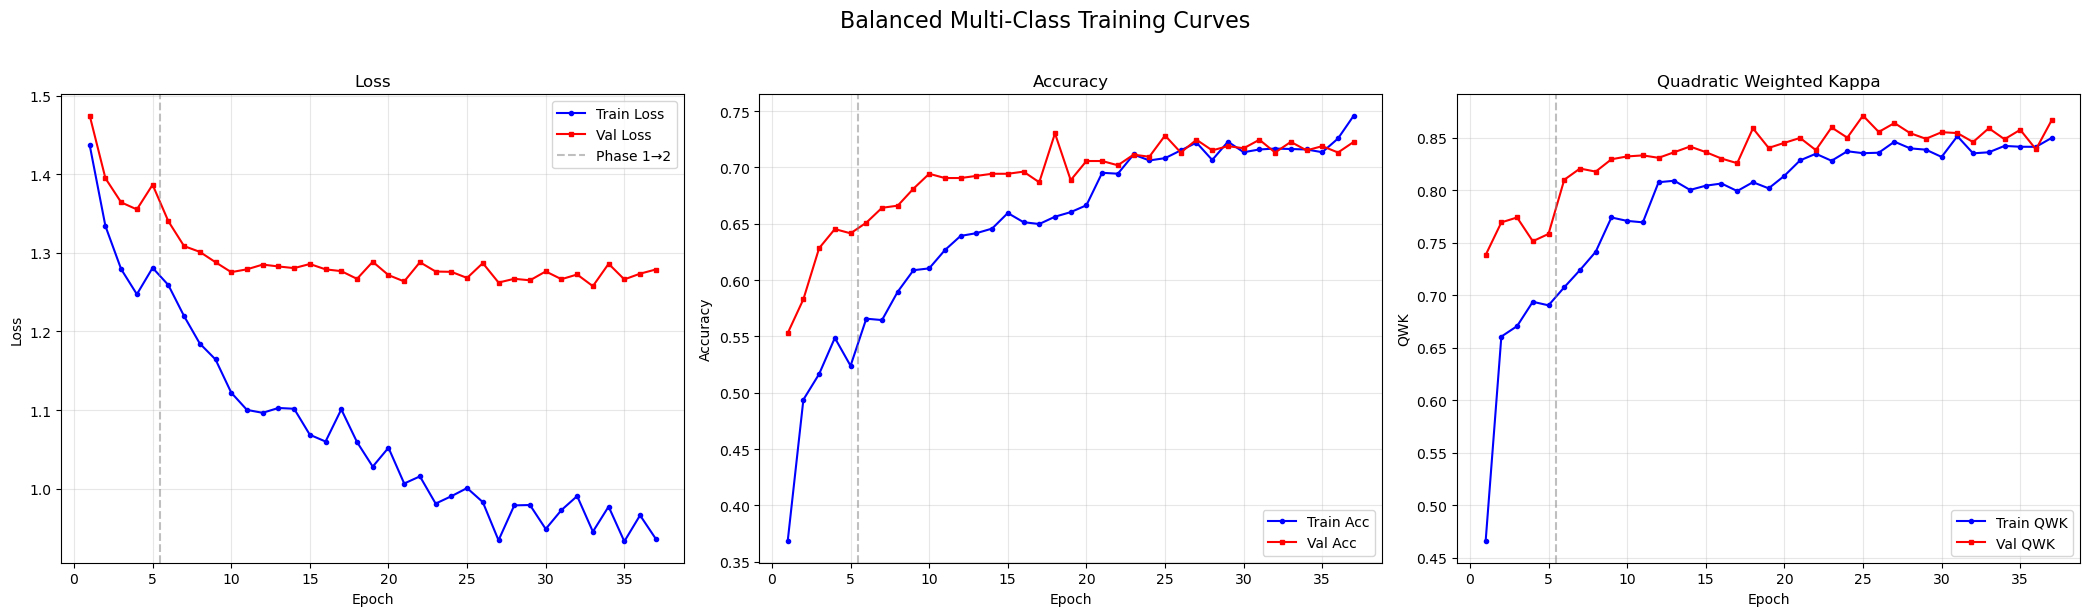

Saved: figures/balanced_training_curves.png


In [20]:
# ============================================================
# 10. Plot training curves
# ============================================================
df_h = df_history.copy()
phase1_end = CONFIG["phase1_epochs"]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Balanced Multi-Class Training Curves", fontsize=16, y=1.02)

# Loss
ax = axes[0]
ax.plot(df_h["epoch"], df_h["train_loss"], "b-o", markersize=3, label="Train Loss")
ax.plot(df_h["epoch"], df_h["val_loss"], "r-s", markersize=3, label="Val Loss")
ax.axvline(x=phase1_end + 0.5, color="gray", linestyle="--", alpha=0.5, label="Phase 1→2")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(df_h["epoch"], df_h["train_acc"], "b-o", markersize=3, label="Train Acc")
ax.plot(df_h["epoch"], df_h["val_acc"], "r-s", markersize=3, label="Val Acc")
ax.axvline(x=phase1_end + 0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

# QWK
ax = axes[2]
ax.plot(df_h["epoch"], df_h["train_qwk"], "b-o", markersize=3, label="Train QWK")
ax.plot(df_h["epoch"], df_h["val_qwk"], "r-s", markersize=3, label="Val QWK")
ax.axvline(x=phase1_end + 0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("QWK")
ax.set_title("Quadratic Weighted Kappa")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "balanced_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'balanced_training_curves.png'}")

## 11. Quick Validation Report

In [22]:
# ============================================================
# 11. Quick validation report on best model
# ============================================================

# Load best model
model.load_state_dict(best_model_state)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 60)
print("VALIDATION RESULTS — BALANCED MODEL")
print("=" * 60)
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"QWK:      {quadratic_weighted_kappa(all_labels, all_preds):.4f}")
print(f"\nPer-class:")
grade_names = ['G0: No DR', 'G1: Mild', 'G2: Moderate', 'G3: Severe', 'G4: PDR']
print(classification_report(all_labels, all_preds, target_names=grade_names, digits=4, zero_division=0))

# Compare with original model
original_qwk = 0.8636  # from original Notebook 04
new_qwk = quadratic_weighted_kappa(all_labels, all_preds)
print(f"\nOriginal model val QWK: {original_qwk:.4f}")
print(f"Balanced model val QWK: {new_qwk:.4f}")
print(f"Difference: {new_qwk - original_qwk:+.4f}")

Evaluating: 100%|███████████████████████████████| 34/34 [00:10<00:00,  3.23it/s]

VALIDATION RESULTS — BALANCED MODEL
Accuracy: 0.7283
QWK:      0.8711

Per-class:
              precision    recall  f1-score   support

   G0: No DR     0.9805    0.9296    0.9544       270
    G1: Mild     0.4583    0.8000    0.5828        55
G2: Moderate     0.8571    0.3360    0.4828       125
  G3: Severe     0.2727    0.7273    0.3967        33
     G4: PDR     0.6098    0.5319    0.5682        47

    accuracy                         0.7283       530
   macro avg     0.6357    0.6650    0.5970       530
weighted avg     0.8203    0.7283    0.7356       530


Original model val QWK: 0.8636
Balanced model val QWK: 0.8711
Difference: +0.0075


## 12. Summary

### What changed from Notebook 04:

| Feature | Notebook 04 (Original) | Notebook 18 (Balanced) |
|---------|----------------------|------------------------|
| Sampling | Random shuffle | WeightedRandomSampler (power=0.5) |
| Loss weights | Class weights | Class weights (same) |
| Augmentation | Standard | Standard + Mixup (α=0.2, p=0.3) |
| Phase 2 epochs | 30 | 40 |
| Early stop patience | 10 | 12 |
| Extra aug | — | HueSaturation, GaussNoise, GaussBlur |
| Output model | `best_multiclass_model.pth` | `best_multiclass_balanced_model.pth` |

### Run Notebook 17 after this to evaluate the balanced model on the test set.